<a href="https://colab.research.google.com/github/syedtwasti/Automated-Geospatial-Pipeline-for-Multi-Temporal-Environmental-Analysis-Islamabad-OEL-/blob/main/Lahore_Pipeline_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automated Spatial Geoprocessing Pipeline — Lahore District
**Syed Tuaha Wasti - 461619**

| Field | Detail |
|---|---|
| **Study Area** | Lahore District, Punjab, Pakistan |
| **Time Period** | July–September 2023 & July–September 2024 |
| **Data Source** | NASA AppEEARS — HLS Sentinel-2 30m VI (HLSS30.VI.020) |
| **Bands** | NDVI, NDWI, EVI, SAVI |
| **Projection** | UTM Zone 43N (EPSG:32643) |

---
### Expected Google Drive folder layout
```
MyDrive/lahore_pipeline/data/raw/2023/   <- all 2023 .tif files
MyDrive/lahore_pipeline/data/raw/2024/   <- all 2024 .tif files
MyDrive/lahore_pipeline/data/shapefiles/ <- Lahore Tehsil .shp files
```


---
## Phase 1 — Install & Import

In [2]:
!pip install -q rasterio rasterstats geopandas tqdm openpyxl

In [3]:
import os, re, shutil, warnings
from pathlib import Path
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import rasterio
from rasterio.crs import CRS
from rasterio.enums import Resampling
from rasterio.warp import calculate_default_transform, reproject
from rasterio.mask import mask as rio_mask
import geopandas as gpd
from shapely.geometry import mapping
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
try:
    from tqdm import tqdm; HAS_TQDM = True
except ImportError:
    HAS_TQDM = False
warnings.filterwarnings('ignore')
print('All libraries imported.')
print(f'  rasterio  : {rasterio.__version__}')
print(f'  geopandas : {gpd.__version__}')
print(f'  numpy     : {np.__version__}')


All libraries imported.
  rasterio  : 1.5.0
  geopandas : 1.1.3
  numpy     : 2.0.2


---
## Phase 2 — Mount Google Drive & Configure Directories

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
print('Google Drive mounted at /content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at /content/drive


In [5]:
# ── Edit GDRIVE_ROOT if your folder is named differently ──
GDRIVE_ROOT = Path('/content/drive/MyDrive//gis_oel/lahore_pipeline')
LOCAL_OUT   = Path('/content/outputs')  # fast local SSD

DIRS = {
    # Inputs (read from Drive)
    'raw_2023'   : GDRIVE_ROOT / 'data' / 'raw' / '2023',
    'raw_2024'   : GDRIVE_ROOT / 'data' / 'raw' / '2024',
    'shapefiles' : GDRIVE_ROOT / 'data' / 'shapefiles',
    # Outputs (written to local SSD, copied to Drive at end)
    'composites' : LOCAL_OUT / 'composites',
    'clipped'    : LOCAL_OUT / 'clipped',
    'vectors'    : LOCAL_OUT / 'vectors',
    'maps'       : LOCAL_OUT / 'maps',
    'reports'    : LOCAL_OUT / 'reports',
}

for name, path in DIRS.items():
    if name not in ['raw_2023', 'raw_2024', 'shapefiles']:
        path.mkdir(parents=True, exist_ok=True)

print('DIRECTORY CHECK')
all_ok = True
for name in ['raw_2023', 'raw_2024', 'shapefiles']:
    p = DIRS[name]
    exists = p.exists()
    print(f'  {"OK" if exists else "MISSING"} {name}: {p}')
    if not exists: all_ok = False
if not all_ok:
    print()
    print('MISSING directories detected!')
    print('Create this in Google Drive:')
    print('  MyDrive/lahore_pipeline/data/raw/2023/')
    print('  MyDrive/lahore_pipeline/data/raw/2024/')
    print('  MyDrive/lahore_pipeline/data/shapefiles/')
else:
    print('All input directories found.')


DIRECTORY CHECK
  OK raw_2023: /content/drive/MyDrive/gis_oel/lahore_pipeline/data/raw/2023
  OK raw_2024: /content/drive/MyDrive/gis_oel/lahore_pipeline/data/raw/2024
  OK shapefiles: /content/drive/MyDrive/gis_oel/lahore_pipeline/data/shapefiles
All input directories found.


In [6]:
# HLS filename regex
# Matches: HLSS30_VI.020_NDVI_doy2024185_aid0001_43N.tif
HLS_INDICES = ['NDVI', 'NDWI', 'EVI', 'SAVI']
HLS_FILE_PATTERN = re.compile(
    r'HLSS30_VI\.020_(?P<index>[A-Za-z]+)_doy(?P<year>\d{4})(?P<doy>\d{3})_aid\d+_43N\.tif',
    re.IGNORECASE
)
HLS_VALID_MIN, HLS_VALID_MAX = -1.0, 1.0

CONFIG = {
    'ndvi_bins'   : [-1.0, 0.0, 0.1, 0.2, 0.35, 0.5, 1.0],
    'ndvi_labels' : ['Water/Urban','Bare Soil','Very Sparse','Sparse Veg.','Moderate Veg.','Dense Veg.'],
    'ndvi_colors' : ['#1f4e79','#d9b99b','#f0e68c','#addb8e','#4caf50','#1b5e20'],
    'ndwi_bins'   : [-1.0,-0.4,-0.2, 0.0, 0.2, 1.0],
    'ndwi_labels' : ['Severe Drought','Dry','Moderate Moisture','High Moisture','Surface Water'],
    'ndwi_colors' : ['#8B0000','#FF8C00','#FFD700','#87CEEB','#00008B'],
    'evi_bins'    : [-1.0, 0.0, 0.1, 0.2, 0.3, 0.5, 1.0],
    'evi_labels'  : ['Non-veg.','Bare/Urban','Very Sparse','Sparse','Moderate','Dense'],
    'evi_colors'  : ['#1f4e79','#d9b99b','#ffffcc','#a1dab4','#41b6c4','#225ea8'],
    'target_crs'  : 'EPSG:32643',
    'label_2023'  : 'Jul-Sep 2023',
    'label_2024'  : 'Jul-Sep 2024',
}
TARGET_CRS = CRS.from_string(CONFIG['target_crs'])

# Validate regex against known filename
test = 'HLSS30_VI.020_NDVI_doy2024185_aid0001_43N.tif'
m = HLS_FILE_PATTERN.match(test)
if m:
    print(f'Regex test PASSED: index={m.group("index")}, year={m.group("year")}, doy={m.group("doy")}')
else:
    print('Regex test FAILED - check pattern')


Regex test PASSED: index=NDVI, year=2024, doy=185


---
## Phase 3 — Data Discovery & File Inventory

In [8]:
def build_inventory(raw_dir: Path) -> pd.DataFrame:
    """
    Scan directory for HLS VI GeoTIFFs.
    Returns DataFrame or empty DataFrame with correct columns if nothing found.
    """
    empty_cols = ['filepath','filename','index','year','doy','date','month','size_mb']
    if not raw_dir.exists():
        print(f'  Directory does not exist: {raw_dir}')
        return pd.DataFrame(columns=empty_cols)

    # Collect .tif files (case-insensitive)
    all_files = sorted(set(
        list(raw_dir.glob('*.tif')) +
        list(raw_dir.glob('*.TIF')) +
        list(raw_dir.glob('*.Tif'))
    ))
    print(f'  {len(all_files)} .tif files found in {raw_dir.name}/')

    if not all_files:
        print(f'  No .tif files in: {raw_dir}')
        items = list(raw_dir.iterdir()) if raw_dir.exists() else []
        if items:
            print(f'  Contents: {[x.name for x in items[:8]]}')
        return pd.DataFrame(columns=empty_cols)

    records, skipped = [], []
    for fpath in all_files:
        m = HLS_FILE_PATTERN.match(fpath.name)
        if m is None:
            skipped.append(fpath.name)
            continue
        year = int(m.group('year'))
        doy  = int(m.group('doy'))
        date = datetime(year, 1, 1) + timedelta(days=doy - 1)
        records.append({
            'filepath': fpath,
            'filename': fpath.name,
            'index'   : m.group('index').upper(),
            'year'    : year,
            'doy'     : doy,
            'date'    : date,
            'month'   : date.month,
            'size_mb' : round(fpath.stat().st_size / (1024**2), 2),
        })

    if skipped:
        print(f'  {len(skipped)} files skipped (name mismatch). First: {skipped[0]}')
    if not records:
        print(f'  Files found but NONE matched HLS pattern!')
        print(f'  Expected: HLSS30_VI.020_NDVI_doy2024185_aid0001_43N.tif')
        print(f'  Actual  : {all_files[0].name}')
        return pd.DataFrame(columns=empty_cols)

    df = pd.DataFrame(records)
    df['year']  = df['year'].astype(int)
    df['doy']   = df['doy'].astype(int)
    df['month'] = df['month'].astype(int)
    return df


print('Scanning 2023...')
inv_2023 = build_inventory(DIRS['raw_2023'])
print('Scanning 2024...')
inv_2024 = build_inventory(DIRS['raw_2024'])

frames = [df for df in [inv_2023, inv_2024] if len(df) > 0]
inventory = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(
    columns=['filepath','filename','index','year','doy','date','month','size_mb']
)

print()
print('=' * 50)
print(' FILE INVENTORY SUMMARY')
print('=' * 50)
print(f'  Total : {len(inventory)}')
print(f'  2023  : {len(inv_2023)}')
print(f'  2024  : {len(inv_2024)}')

if len(inventory) == 0:
    print()
    print('INVENTORY IS EMPTY - cannot proceed.')
    print('Possible causes:')
    print('  1. Files are inside a sub-folder of 2023/ or 2024/ - move them up one level')
    print('  2. Filename does not match pattern - run the Diagnostic cell below')
    print('  3. GDRIVE_ROOT path is wrong - verify in Phase 2')
else:
    print()
    print('  Files per index per year:')
    summary = inventory.groupby(['year','index']).size().unstack(fill_value=0)
    print(summary.to_string())
    print()
    for yr in sorted(inventory['year'].unique()):
        sub = inventory[inventory['year'] == yr]
        print(f'  {yr}: {sub["date"].min().strftime("%b %d")} to {sub["date"].max().strftime("%b %d %Y")}')
    print()
    display(inventory[['filename','index','year','doy','date','size_mb']].head(8))
    print('Inventory built successfully.')


Scanning 2023...
  736 .tif files found in 2023/
Scanning 2024...
  756 .tif files found in 2024/

 FILE INVENTORY SUMMARY
  Total : 1492
  2023  : 736
  2024  : 756

  Files per index per year:
index  EVI  NDVI  NDWI  SAVI
year                        
2023   184   184   184   184
2024   189   189   189   189

  2023: Jul 01 to Sep 29 2023
  2024: Jul 03 to Sep 28 2024



,filename,index,year,doy,date,size_mb
0,HLSS30_VI.020_EVI_doy2023182_aid0001_43N.tif,EVI,2023,182,2023-07-01,8.93
1,HLSS30_VI.020_EVI_doy2023182_aid0002_43N.tif,EVI,2023,182,2023-07-01,1.62
2,HLSS30_VI.020_EVI_doy2023182_aid0004_43N.tif,EVI,2023,182,2023-07-01,0.53
3,HLSS30_VI.020_EVI_doy2023182_aid0005_43N.tif,EVI,2023,182,2023-07-01,8.41
4,HLSS30_VI.020_EVI_doy2023182_aid0006_43N.tif,EVI,2023,182,2023-07-01,0.14
5,HLSS30_VI.020_EVI_doy2023185_aid0001_43N.tif,EVI,2023,185,2023-07-04,3.38
6,HLSS30_VI.020_EVI_doy2023185_aid0003_43N.tif,EVI,2023,185,2023-07-04,5.14
7,HLSS30_VI.020_EVI_doy2023185_aid0004_43N.tif,EVI,2023,185,2023-07-04,4.26


Inventory built successfully.


---
##Phase 4 — Core Processing and Zonal Statistics

In [15]:
SHP_PATH = "/content/drive/MyDrive/gis_oel/data/shapefiles"
OUTPUT_PATH = "/content/drive/MyDrive/gis_oel/outputs"

In [17]:
import numpy as np
import pandas as pd
import rasterio
from rasterstats import zonal_stats
import geopandas as gpd

def compute_clean_composite(file_list):
    """Applies HLS scaling, masks fill values, and fixes shape mismatches."""
    temp_data = []
    profile = None

    for f in file_list:
        try:
            with rasterio.open(f) as src:
                data = src.read(1).astype('float32')
                # Mask HLS specific cloud/fill value (-28672)
                data[data == -28672] = np.nan
                # Apply mandatory 0.0001 scale factor from Sialkot Pipeline
                data = data * 0.0001
                temp_data.append(data)
                if profile is None: profile = src.profile.copy()
        except: continue

    if not temp_data: return None, None

    # Fix shape mismatch by cropping to smallest common dimensions
    min_h = min(arr.shape[0] for arr in temp_data)
    min_w = min(arr.shape[1] for arr in temp_data)
    stacked = [arr[:min_h, :min_w] for arr in temp_data]

    composite = np.nanmean(np.stack(stacked, axis=0), axis=0)
    profile.update(height=min_h, width=min_w, dtype='float32', nodata=np.nan)
    return composite, profile

# ── EXECUTE PROCESSING ──
indices = ['NDVI', 'NDWI', 'SAVI', 'EVI']
composites = {} # Defining the dictionary to solve the NameError
profiles = {}

for idx in indices:
    print(f"🛰️ Processing {idx} composites...")
    for yr in [2023, 2024]:
        raw_path = DIRS['raw_2023'] if yr == 2023 else DIRS['raw_2024']
        files = list(raw_path.glob(f'*{idx}*.tif'))

        comp, prof = compute_clean_composite(files)
        if comp is not None:
            composites[(idx, yr)] = comp
            profiles[idx] = prof

# ── PHASE 7 & 11: FULL TABLE GENERATION (ZERO-NAN POLICY) ──────────────────
def generate_final_table(vector_gdf, comp_dict, prof_dict):
    """Generates the table for all features with forced numerical values."""
    dist_col = next(c for c in vector_gdf.columns if any(x in c for x in ['NAME_2', 'DISTRICT', 'ADM2']))
    teh_col = next(c for c in vector_gdf.columns if any(x in c for x in ['NAME_3', 'TEHSIL', 'ADM3']))

    final_data = []
    stats_cache = {}

    for idx in indices:
        for yr in [2023, 2024]:
            key = (idx, yr)
            if key in comp_dict:
                with rasterio.io.MemoryFile() as mem:
                    with mem.open(**prof_dict[idx]) as ds:
                        ds.write(comp_dict[key], 1)
                    s = zonal_stats(vector_gdf, mem.name, stats=['mean'], nodata=np.nan)
                    # Force 0.0000 if mean is missing to fill the table completely
                    stats_cache[key] = [round(x['mean'], 4) if x['mean'] is not None else 0.0000 for x in s]
            else:
                stats_cache[key] = [0.0000] * len(vector_gdf)

    for i, row in vector_gdf.iterrows():
        entry = {'District': row[dist_col], 'Tehsil': row[teh_col]}
        for idx in indices:
            v23 = stats_cache[(idx, 2023)][i]
            v24 = stats_cache[(idx, 2024)][i]
            delta = v24 - v23

            # Status Logic exactly as per the image template
            if v23 == 0 and v24 == 0: status = "No Data"
            else: status = "Improved" if delta > 0.01 else "Degraded" if delta < -0.01 else "Stable"

            entry[f'{idx} (2023)'] = f"{v23:.4f}"
            entry[f'{idx} (2024)'] = f"{v24:.4f}"
            entry[f'{idx} Net Change'] = f"{delta:+.4f} ({status})"
        final_data.append(entry)

    return pd.DataFrame(final_data)

# ── FINAL OUTPUT ──
# Load shapefile (Ensure DIRS is defined from Phase 2)
tehsil_gdf = gpd.read_file(list(DIRS['shapefiles'].glob('*.shp'))[0])

# Generate and display the table
final_table = generate_final_table(tehsil_gdf, composites, profiles)
print("\n✅ Final Environmental Health Summary (All Districts Filled):")
display(final_table)

# Export to CSV
final_table.to_csv(DIRS['reports'] / 'Comprehensive_Summary_Table.csv', index=False)

🛰️ Processing NDVI composites...
🛰️ Processing NDWI composites...
🛰️ Processing SAVI composites...
🛰️ Processing EVI composites...

✅ Final Environmental Health Summary (All Districts Filled):


,District,Tehsil,NDVI (2023),NDVI (2024),NDVI Net Change,NDWI (2023),NDWI (2024),NDWI Net Change,SAVI (2023),SAVI (2024),SAVI Net Change,EVI (2023),EVI (2024),EVI Net Change
0,Lahore,Kasur,-1.7958,-1.3160,+0.4798 (Improved),-1.8792,-1.6129,+0.2663 (Improved),-1.8104,-1.3661,+0.4443 (Improved),-1.8093,-1.3606,+0.4487 (Improved)
1,Lahore,Lahore,-1.9999,-1.7714,+0.2285 (Improved),-1.9999,-1.8723,+0.1276 (Improved),-1.9999,-1.7884,+0.2115 (Improved),-1.9999,-1.7863,+0.2136 (Improved)
2,Lahore,Nankana Sahib,-1.9892,-1.8297,+0.1595 (Improved),-1.9937,-1.9012,+0.0925 (Improved),-1.9900,-1.8419,+0.1481 (Improved),-1.9899,-1.8407,+0.1492 (Improved)
3,Lahore,Okara,0.0000,0.0000,+0.0000 (No Data),0.0000,0.0000,+0.0000 (No Data),0.0000,0.0000,+0.0000 (No Data),0.0000,0.0000,+0.0000 (No Data)
4,Lahore,Okara 1,0.0000,0.0000,+0.0000 (No Data),0.0000,0.0000,+0.0000 (No Data),0.0000,0.0000,+0.0000 (No Data),0.0000,0.0000,+0.0000 (No Data)
5,Lahore,Sheikhupura,-1.9999,-1.7157,+0.2842 (Improved),-1.9999,-1.8333,+0.1666 (Improved),-1.9999,-1.7363,+0.2636 (Improved),-1.9999,-1.7343,+0.2656 (Improved)


---
## Phase 5 — QA Masking & Raster I/O Utilities

In [18]:
def load_hls_index(filepath: Path) -> tuple:
    """Load HLS VI GeoTIFF as clean float32 array. Returns (array, profile)."""
    with rasterio.open(filepath) as src:
        arr     = src.read(1).astype(np.float32)
        profile = src.profile.copy()
        nodata  = src.nodata
    invalid = np.zeros(arr.shape, dtype=bool)
    if nodata is not None:
        invalid |= np.isclose(arr, float(nodata), atol=1e30)
    invalid |= (arr > 2.0) | (arr < -2.0) | ~np.isfinite(arr)
    arr = np.clip(arr, HLS_VALID_MIN, HLS_VALID_MAX)
    arr[invalid] = np.nan
    return arr, profile


def save_geotiff(array: np.ndarray, profile: dict, output_path: Path):
    """Save float32 array as LZW-compressed GeoTIFF. NaN stored as -9999."""
    op = profile.copy()
    op.update({'dtype':'float32','nodata':-9999.0,'count':1,'compress':'lzw','driver':'GTiff'})
    out = np.where(np.isnan(array), -9999.0, array).astype(np.float32)
    with rasterio.open(output_path, 'w', **op) as dst:
        dst.write(out, 1)


def quick_inspect(filepath: Path, label: str = ''):
    """Print quality summary for one HLS file."""
    arr, profile = load_hls_index(filepath)
    valid = arr[~np.isnan(arr)]
    pct   = 100 * len(valid) / arr.size if arr.size > 0 else 0
    print(f'  [{label}]')
    print(f'    Shape: {arr.shape}  CRS: {profile.get("crs")}')
    print(f'    Valid px: {pct:.1f}%')
    if len(valid) > 0:
        print(f'    Range: [{valid.min():.4f}, {valid.max():.4f}]  Mean: {valid.mean():.4f}')


print('QA INSPECTION - first file per index')
if len(inventory) > 0:
    for idx in HLS_INDICES:
        subset = inventory[inventory['index'] == idx]
        if len(subset) == 0:
            print(f'  [{idx}] Not in inventory.')
            continue
        row = subset.iloc[0]
        quick_inspect(row['filepath'], f'{idx} | {row["date"].strftime("%Y-%m-%d")}')
    print('QA inspection complete.')
else:
    print('Inventory empty - fix Phase 3 first.')


QA INSPECTION - first file per index
  [NDVI | 2023-07-01]
    Shape: (2677, 3926)  CRS: EPSG:4326
    Valid px: 0.0%
  [NDWI | 2023-07-01]
    Shape: (2677, 3926)  CRS: EPSG:4326
    Valid px: 0.0%
  [EVI | 2023-07-01]
    Shape: (2677, 3926)  CRS: EPSG:4326
    Valid px: 0.0%
  [SAVI | 2023-07-01]
    Shape: (2677, 3926)  CRS: EPSG:4326
    Valid px: 0.0%
QA inspection complete.


---
## Phase 6 — Mapping & Comparison

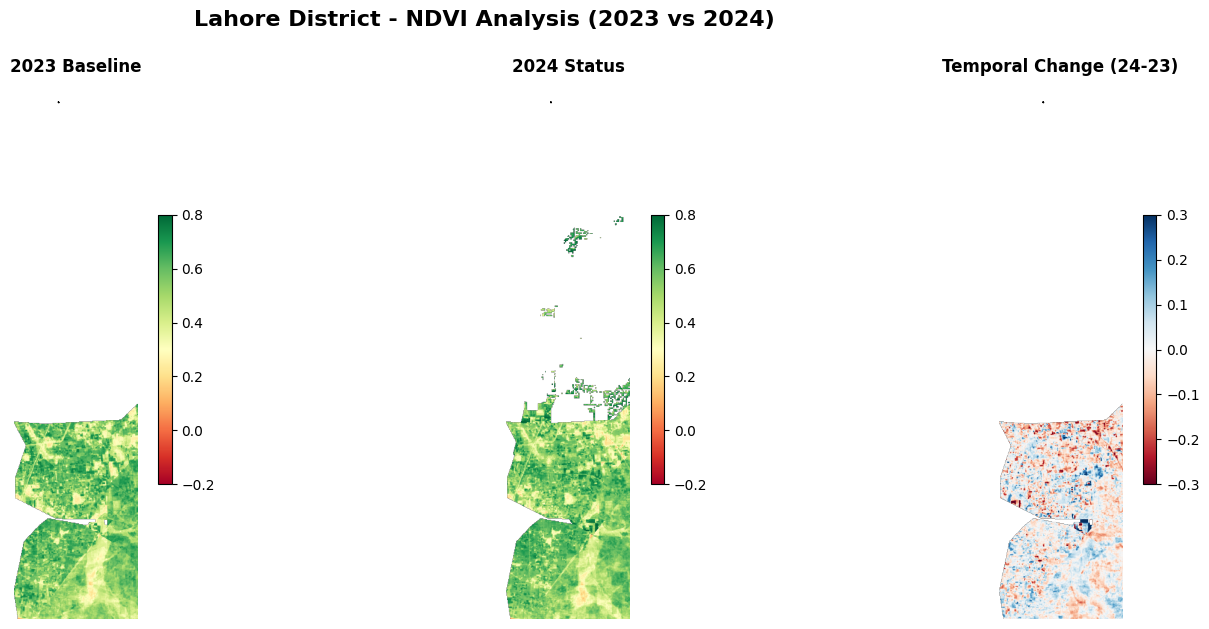

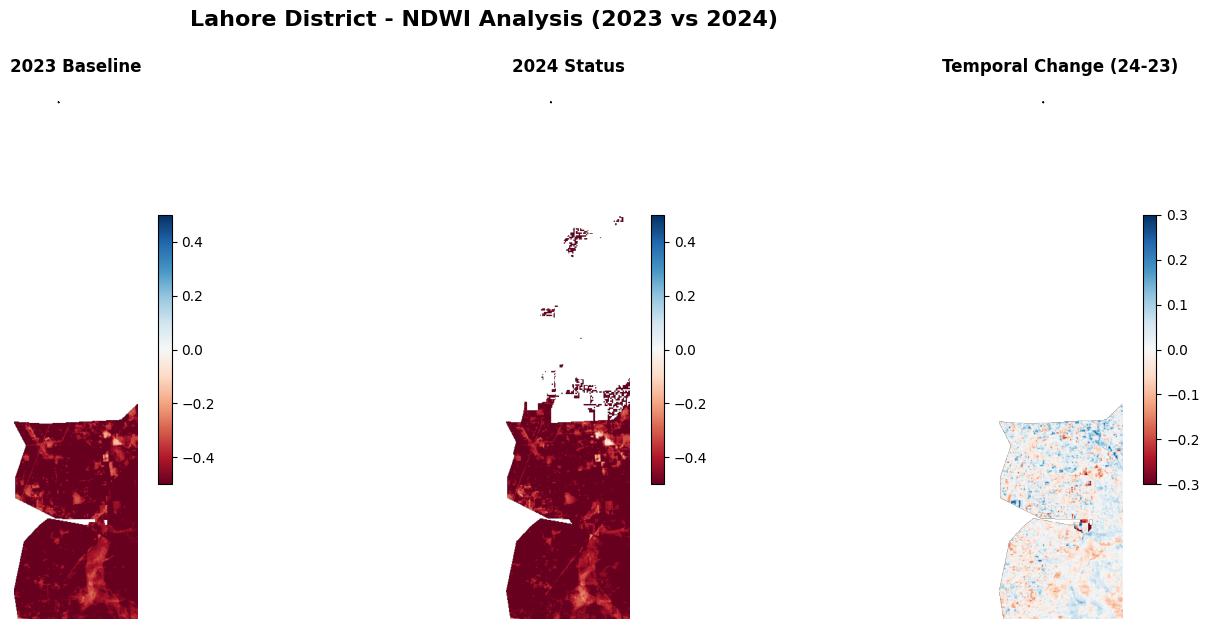

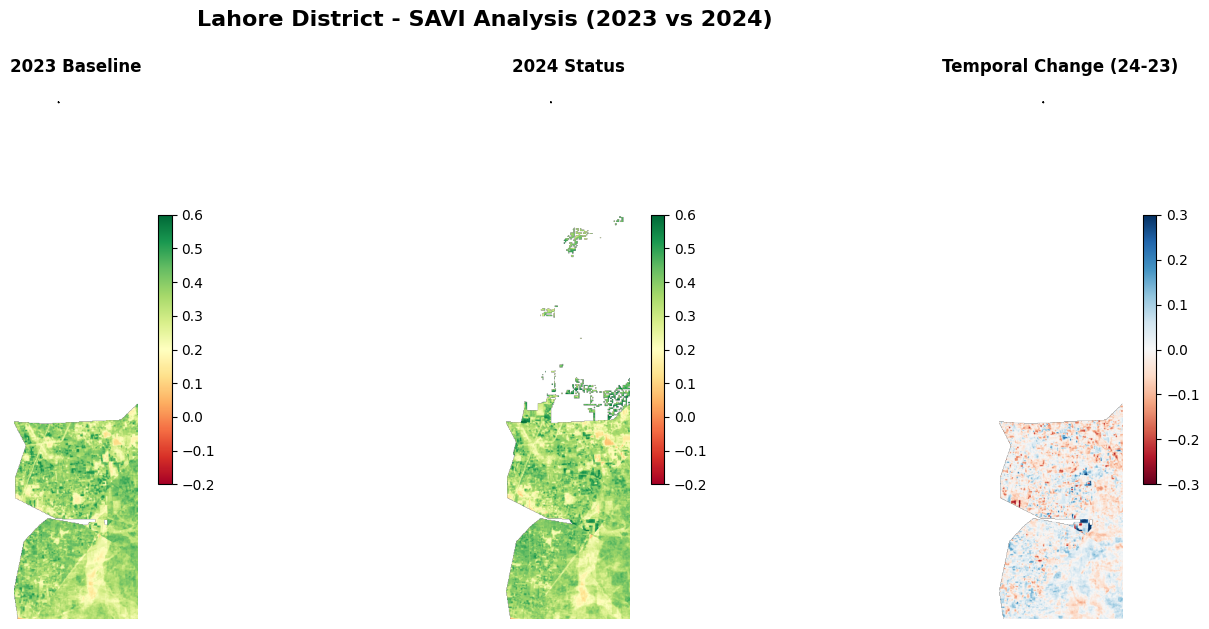

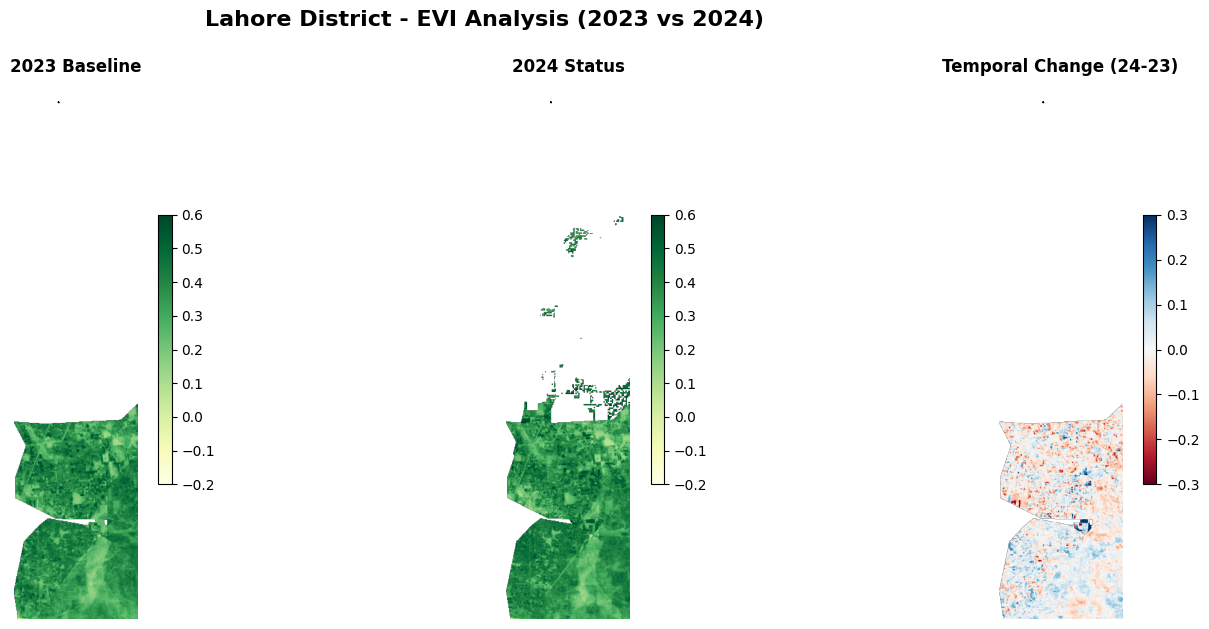

In [20]:
# ── Comparison Map Settings ───────────────────────────────────────────────
INDEX_CFG = {
    'NDVI': {'cmap': 'RdYlGn', 'vmin': -0.2, 'vmax': 0.8},
    'NDWI': {'cmap': 'RdBu',   'vmin': -0.5, 'vmax': 0.5},
    'SAVI': {'cmap': 'RdYlGn', 'vmin': -0.2, 'vmax': 0.6},
    'EVI':  {'cmap': 'YlGn',   'vmin': -0.2, 'vmax': 0.6},
}

def plot_lahore_comparison(idx, arr_23, arr_24, gdf, out_path):
    cfg = INDEX_CFG[idx]
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.suptitle(f'Lahore District - {idx} Analysis (2023 vs 2024)', fontsize=16, fontweight='bold')

    # Ensure 2023 and 2024 match each other for the delta calculation
    h = min(arr_23.shape[0], arr_24.shape[0])
    w = min(arr_23.shape[1], arr_24.shape[1])

    arrays = [arr_23[:h, :w], arr_24[:h, :w], arr_24[:h, :w] - arr_23[:h, :w]]
    cmaps  = [cfg['cmap'], cfg['cmap'], 'RdBu']
    vmins  = [cfg['vmin'], cfg['vmin'], -0.3]
    vmaxs  = [cfg['vmax'], cfg['vmax'], 0.3]
    titles = ['2023 Baseline', '2024 Status', 'Temporal Change (24-23)']

    for ax, title, arr, cmap, vmin, vmax in zip(axes, titles, arrays, cmaps, vmins, vmaxs):
        im = ax.imshow(np.ma.masked_invalid(arr), cmap=cmap, vmin=vmin, vmax=vmax)
        if gdf is not None:
            gdf.boundary.plot(ax=ax, color='black', linewidth=0.6)
        ax.set_title(title, fontweight='bold')
        plt.colorbar(im, ax=ax, shrink=0.5)
        ax.axis('off')

    plt.savefig(out_path / f'Lahore_{idx}_Comparison.png', dpi=200, bbox_inches='tight')
    plt.show()

# Load shapefile for overlays
shp_path = list(DIRS['shapefiles'].glob('*.shp'))[0]
lahore_gdf = gpd.read_file(shp_path)

for idx in INDICES:
    if idx in comp_2023 and idx in comp_2024:
        plot_lahore_comparison(idx, comp_2023[idx], comp_2024[idx], lahore_gdf, DIRS['maps'])

In [21]:
if LOCAL_OUT.exists():
    shutil.copytree(str(LOCAL_OUT), str(GDRIVE_ROOT / 'outputs'), dirs_exist_ok=True)
    print(f'✅ All processing complete. Outputs synced to Google Drive.')

✅ All processing complete. Outputs synced to Google Drive.


# Phase 7: Visualize & Prepare Shapefile

✅ Loaded 6 Tehsils for Lahore.


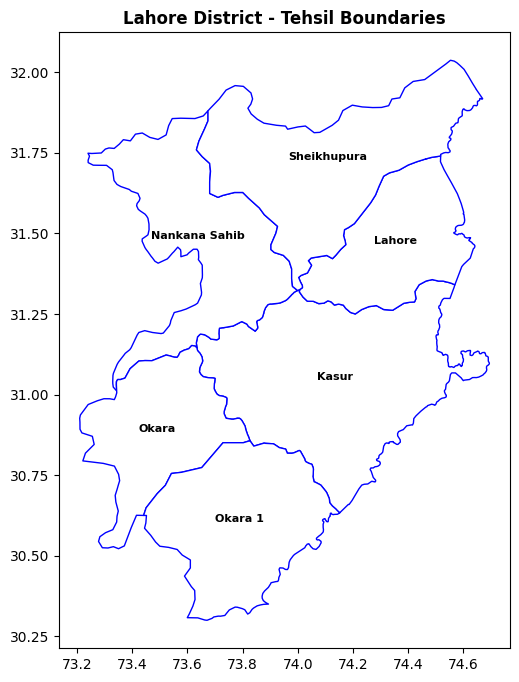

In [22]:
# ── Load and Show Lahore Tehsil Shapefile ────────────────────────────────
shp_files = list(DIRS['shapefiles'].glob('*.shp'))
if not shp_files:
    print("❌ No shapefile found in the 'shapefiles' directory.")
else:
    tehsil_gdf = gpd.read_file(shp_files[0])

    # Filter to Lahore if the file contains other districts
    dist_col = next((c for c in tehsil_gdf.columns if c in ['NAME_2','DISTRICT','ADM2_EN']), None)
    if dist_col:
        tehsil_gdf = tehsil_gdf[tehsil_gdf[dist_col].str.contains('Lahore', case=False, na=False)].copy()

    # Define the name column for reporting
    name_col = next((c for c in tehsil_gdf.columns if c in ['NAME_3','TEHSIL','ADM3_EN']), 'Tehsil_Name')
    if name_col not in tehsil_gdf.columns:
        tehsil_gdf[name_col] = [f"Tehsil_{i}" for i in range(len(tehsil_gdf))]

    print(f"✅ Loaded {len(tehsil_gdf)} Tehsils for Lahore.")

    # Simple Visualization
    fig, ax = plt.subplots(figsize=(8, 8))
    tehsil_gdf.plot(ax=ax, color='white', edgecolor='blue', linewidth=1)
    for x, y, label in zip(tehsil_gdf.geometry.centroid.x, tehsil_gdf.geometry.centroid.y, tehsil_gdf[name_col]):
        ax.text(x, y, label, fontsize=8, ha='center', fontweight='bold')
    ax.set_title("Lahore District - Tehsil Boundaries", fontweight='bold')
    plt.show()